**Data Analysis and Visualization**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/real_estate_dataset.csv")

In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028 sqft,Residential land / Plot,0,2317000.0,Jigani
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere


In [ ]:
df['size'] = (
    df['size']
    .astype(str)
    .str.lower()
    .str.replace(r'sq\.?\s*ft\.?', '', regex=True)
    .str.replace(r'sqft\.?', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)



In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028,Residential land / Plot,0,2317000.0,Jigani
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085,2 BHK Flat,2,12500000.0,Tumkur Road
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837,"3, 4 BHK Apartment",0,23200000.0,Whitefield
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830,"2, 3 BHK Apartment",0,889000.0,Soukya Road
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314,"2, 3 BHK Apartment",0,6483000.0,Kalkere


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# fill numeric nulls with median (better for real-estate data)
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


print(df.isnull().sum())

url             0
beds            0
city            0
date            0
size            0
type            0
baths           0
price           0
neighborhood    0
dtype: int64


In [ ]:
df.tail(20)

,url,beds,city,date,size,type,baths,price,neighborhood
267,https://www.99acres.com/residential-land-plot-...,0,Chennai,19-02-2025,1680,Residential land / Plot,0,4800000.00,"Maraimalai Nagar, GST Road"
268,https://www.99acres.com/residential-land-plot-...,0,Navi Mumbai,19-02-2025,1089,Residential land / Plot,0,5.15,Chirle
269,https://www.99acres.com/residential-land-plot-...,0,Navi Mumbai,19-02-2025,1089,Residential land / Plot,0,9.00,Panvel
270,https://www.99acres.com/1-bhk-bedroom-independ...,1,Mumbai,19-02-2025,300,1 Bedroom House,1,15.00,Nalanda Nagar
271,https://www.99acres.com/1-bhk-bedroom-independ...,1,Mumbai,19-02-2025,400,1 BHK Independent Builder Floor,1,15.00,Badlapur Vangani
272,https://www.99acres.com/studio-apartment-flat-...,1,Mumbai,19-02-2025,200,Studio Apartments / 1 RK Flats,1,9.00,nallasopara
273,https://www.99acres.com/1-bhk-bedroom-independ...,1,Mumbai,19-02-2025,180,1 Bedroom House,1,15.00,Santacruz East
274,https://www.99acres.com/1-bhk-bedroom-apartmen...,1,Mumbai,19-02-2025,200,1 BHK Flat,1,13.00,Malad West
275,https://www.99acres.com/1-bhk-bedroom-independ...,1,Mumbai,19-02-2025,100,1 BHK Independent Builder Floor,1,13.00,Asalpha
276,https://www.99acres.com/1-bhk-bedroom-independ...,1,Mumbai,19-02-2025,360,1 BHK Independent Builder Floor,1,11.50,Kandivali East


Price Statistics

count    2.870000e+02
mean     1.956434e+07
std      4.461799e+07
min      0.000000e+00
25%      4.738000e+06
50%      1.000000e+07
75%      2.085000e+07
max      6.000000e+08
Name: price, dtype: float64


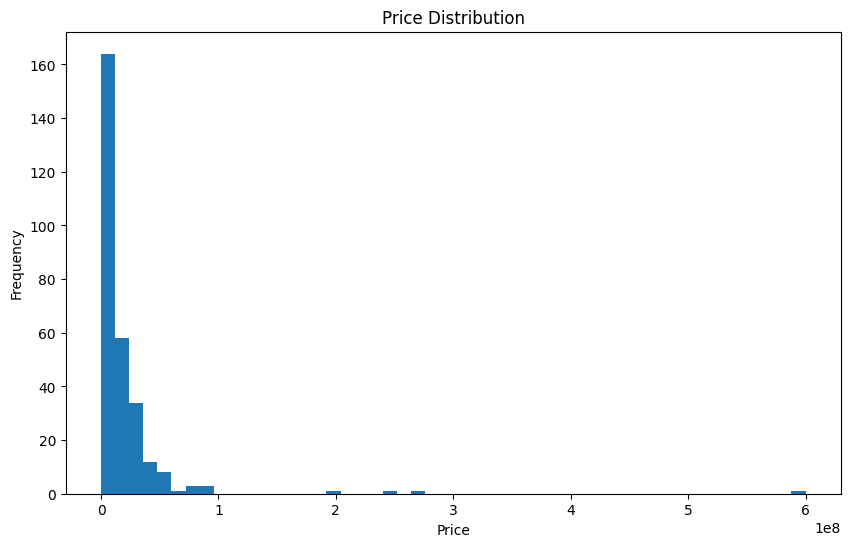

In [ ]:
import matplotlib.pyplot as plt

print("Price Statistics\n")
print(df['price'].describe())
plt.figure(figsize=(10,6))

plt.hist(df['price'], bins=50)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")

plt.show()


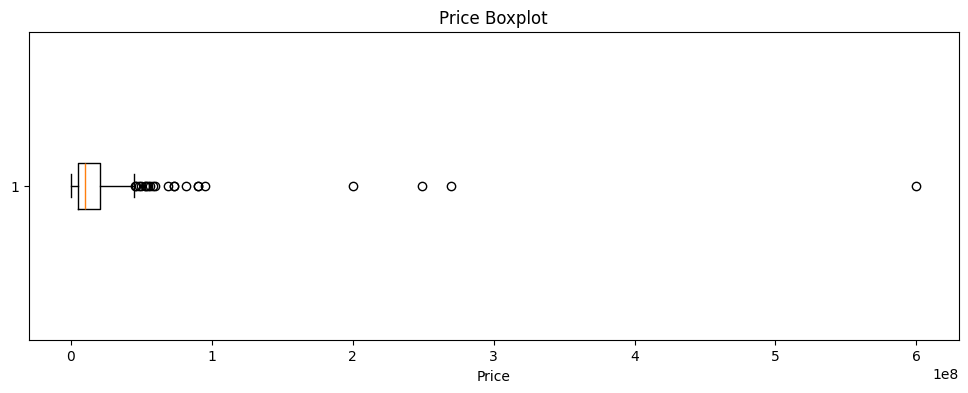

In [ ]:
plt.figure(figsize=(12,4))

plt.boxplot(df['price'], vert=False)

plt.xlabel("Price")
plt.title("Price Boxplot")

plt.show()

In [ ]:
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['price_per_sqft'] = (df['price'] / df['size'])

In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood,price_per_sqft
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028.0,Residential land / Plot,0,2317000.0,Jigani,2253.891051
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085.0,2 BHK Flat,2,12500000.0,Tumkur Road,11520.737327
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837.0,"3, 4 BHK Apartment",0,23200000.0,Whitefield,12629.286881
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830.0,"2, 3 BHK Apartment",0,889000.0,Soukya Road,1071.084337
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314.0,"2, 3 BHK Apartment",0,6483000.0,Kalkere,4933.789954


In [ ]:
df['full_address'] = (
    df['neighborhood'] + ', ' + df['city']
)

**Geospasity**

In [ ]:
!pip install geopy

In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd

# initialize geocoder
geolocator = Nominatim(user_agent="real_estate_project")

# avoid rate limit issues
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1
)

# geocode function
def get_coordinates(address):

    try:
        location = geocode(address)

        if location:
            return pd.Series([
                location.latitude,
                location.longitude
            ])

    except:
        pass

    return pd.Series([None, None])

# apply geocoding
df[['latitude', 'longitude']] = (
    df['full_address']
    .apply(get_coordinates)
)

In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood,price_per_sqft,full_address,latitude,longitude
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028.0,Residential land / Plot,0,2317000.0,Jigani,2253.891051,"Jigani, Bangalore",12.778079,77.635778
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085.0,2 BHK Flat,2,12500000.0,Tumkur Road,11520.737327,"Tumkur Road, Bangalore",13.016796,77.553813
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837.0,"3, 4 BHK Apartment",0,23200000.0,Whitefield,12629.286881,"Whitefield, Bangalore",12.995743,77.757949
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830.0,"2, 3 BHK Apartment",0,889000.0,Soukya Road,1071.084337,"Soukya Road, Bangalore",12.992964,77.796999
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314.0,"2, 3 BHK Apartment",0,6483000.0,Kalkere,4933.789954,"Kalkere, Bangalore",13.034445,77.676678


In [ ]:
df.to_csv(
    "geocoded_real_estate.csv",
    index=False
)

In [ ]:
missing = df.isnull().sum()

print("\nMissing Values Per Column:\n")
print(missing)


Missing Values Per Column:

url                0
beds               0
city               0
date               0
size              54
type               0
baths              0
price              0
neighborhood       0
price_per_sqft    54
full_address       0
latitude          58
longitude         58
dtype: int64


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.1 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import pandas as pd

def count_nearby_hospitals(lat, lon, radius=5000):

    try:
        tags = {'amenity': 'hospital'}

        hospitals = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        return len(hospitals)

    except:
        return 0

In [ ]:
df['hospital_count'] = df.apply(
    lambda row: count_nearby_hospitals(
        row['latitude'],
        row['longitude']
    ),
    axis=1
)

In [ ]:
import osmnx as ox
import pandas as pd
#school
def count_nearby_school(lat, lon, radius=5000):

    try:
        tags = {'amenity': 'school'}

        hospitals = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        return len(school)

    except:
        return 0

  #railway station
import osmnx as ox
import pandas as pd

def count_nearby_station(lat, lon, radius=5000):

    try:
        tags = {'railway': 'station'}

        hospitals = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        return len(station)

    except:
        return 0

In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood,price_per_sqft,full_address,latitude,longitude,hospital_count
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028.0,Residential land / Plot,0,2317000.0,Jigani,2253.891051,"Jigani, Bangalore",12.778079,77.635778,2
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085.0,2 BHK Flat,2,12500000.0,Tumkur Road,11520.737327,"Tumkur Road, Bangalore",13.016796,77.553813,236
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837.0,"3, 4 BHK Apartment",0,23200000.0,Whitefield,12629.286881,"Whitefield, Bangalore",12.995743,77.757949,42
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830.0,"2, 3 BHK Apartment",0,889000.0,Soukya Road,1071.084337,"Soukya Road, Bangalore",12.992964,77.796999,8
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314.0,"2, 3 BHK Apartment",0,6483000.0,Kalkere,4933.789954,"Kalkere, Bangalore",13.034445,77.676678,96


In [ ]:
df['station_count'] = df.apply(
    lambda row: count_nearby_station(
        row['latitude'],
        row['longitude']
    ),
    axis=1
)

In [ ]:
df['school_count'] = df.apply(
    lambda row: count_nearby_school(
        row['latitude'],
        row['longitude']
    ),
    axis=1
)

In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood,price_per_sqft,full_address,latitude,longitude,hospital_count,school_count,station_count
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028.0,Residential land / Plot,0,2317000.0,Jigani,2253.891051,"Jigani, Bangalore",12.778079,77.635778,2,0,0
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085.0,2 BHK Flat,2,12500000.0,Tumkur Road,11520.737327,"Tumkur Road, Bangalore",13.016796,77.553813,236,0,0
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837.0,"3, 4 BHK Apartment",0,23200000.0,Whitefield,12629.286881,"Whitefield, Bangalore",12.995743,77.757949,42,0,0
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830.0,"2, 3 BHK Apartment",0,889000.0,Soukya Road,1071.084337,"Soukya Road, Bangalore",12.992964,77.796999,8,0,0
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314.0,"2, 3 BHK Apartment",0,6483000.0,Kalkere,4933.789954,"Kalkere, Bangalore",13.034445,77.676678,96,0,0


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/geocoded_real_estate.csv")

df.head()


,url,beds,city,date,size,type,baths,price,neighborhood,price_per_sqft,full_address,latitude,longitude
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028.0,Residential land / Plot,0,2317000.0,Jigani,2253.891051,"Jigani, Bangalore",12.778079,77.635778
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085.0,2 BHK Flat,2,12500000.0,Tumkur Road,11520.737327,"Tumkur Road, Bangalore",13.016796,77.553813
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837.0,"3, 4 BHK Apartment",0,23200000.0,Whitefield,12629.286881,"Whitefield, Bangalore",12.995743,77.757949
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830.0,"2, 3 BHK Apartment",0,889000.0,Soukya Road,1071.084337,"Soukya Road, Bangalore",12.992964,77.796999
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314.0,"2, 3 BHK Apartment",0,6483000.0,Kalkere,4933.789954,"Kalkere, Bangalore",13.034445,77.676678


**Collateral Liquidation**

In [ ]:
df['locality_median_pps'] = (
    df.groupby('neighborhood')['price_per_sqft']
    .median()
)

print(locality_median_pps.head())

neighborhood
Ambapuram          4169.272462
Ambari falakata     555.684186
Anakapalle          159.746099
Anand Vihar                NaN
Anandapuram        3055.555556
Name: price_per_sqft, dtype: float64


In [ ]:
df['valuation_ratio'] = (
    df['price_per_sqft']
    /
    df['locality_median_pps']
)

print(df[
    [
        'neighborhood',
        'price_per_sqft',
        'locality_median_pps',
        'valuation_ratio'
    ]
].head())

  neighborhood  price_per_sqft  locality_median_pps  valuation_ratio
0       Jigani     2253.891051                  NaN              NaN
1  Tumkur Road    11520.737327                  NaN              NaN
2   Whitefield    12629.286881                  NaN              NaN
3  Soukya Road     1071.084337                  NaN              NaN
4      Kalkere     4933.789954                  NaN              NaN


In [ ]:
df['fairness_score'] = (
    1 /
    (1 + abs(df['valuation_ratio'] - 1))
)

In [ ]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood,price_per_sqft,full_address,latitude,longitude,locality_median_pps,valuation_ratio,fairness_score
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,19-02-2025,1028.0,Residential land / Plot,0,2317000.0,Jigani,2253.891051,"Jigani, Bangalore",12.778079,77.635778,NaN,NaN,NaN
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,19-02-2025,1085.0,2 BHK Flat,2,12500000.0,Tumkur Road,11520.737327,"Tumkur Road, Bangalore",13.016796,77.553813,NaN,NaN,NaN
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,19-02-2025,1837.0,"3, 4 BHK Apartment",0,23200000.0,Whitefield,12629.286881,"Whitefield, Bangalore",12.995743,77.757949,NaN,NaN,NaN
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,19-02-2025,830.0,"2, 3 BHK Apartment",0,889000.0,Soukya Road,1071.084337,"Soukya Road, Bangalore",12.992964,77.796999,NaN,NaN,NaN
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,19-02-2025,1314.0,"2, 3 BHK Apartment",0,6483000.0,Kalkere,4933.789954,"Kalkere, Bangalore",13.034445,77.676678,NaN,NaN,NaN


In [ ]:
#this code doesnt run rightnow because of our small datset
#this is just a prototype we could work on real world dataset


df['liquidity_score'] = (
    0.4 * df['transit_score'] +
    0.3 * df['school_score'] +
    0.3 * df['fairness_score']
)

# scale to 0-100
df['liquidity_score'] = (
    df['liquidity_score'] * 100
)

print(df[
    [
        'neighborhood',
        'valuation_ratio',
        'transit_score',
        'school_score',
        'liquidity_score'
    ]
].head())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df['liquidity_score'], bins=30)

plt.xlabel("Liquidity Score")
plt.ylabel("Count")
plt.title("Liquidity Score Distribution")

plt.show()

**Anomaly Detection**

In [ ]:
anomaly_features = df[
    [
        'price_per_sqft',
        'valuation_ratio',
        'liquidity_score',
        'sqft',
        'station_count'
    ]
]

In [ ]:
anomaly_features = anomaly_features.fillna(
    anomaly_features.median()
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    anomaly_features
)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # assume 5% anomalies
    random_state=42
)

iso.fit(scaled_features)

In [ ]:
df['anomaly_flag'] = iso.predict(
    scaled_features
)

# convert to readable labels
df['anomaly_flag'] = df['anomaly_flag'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

print(df['anomaly_flag'].value_counts())

In [ ]:
df['anomaly_score'] = (
    iso.decision_function(scaled_features)
)

# normalize to 0-100
min_score = df['anomaly_score'].min()
max_score = df['anomaly_score'].max()

df['risk_score'] = (
    (
        df['anomaly_score'] - min_score
    ) /
    (
        max_score - min_score
    )
) * 100

print(df[
    [
        'neighborhood',
        'anomaly_flag',
        'risk_score'
    ]
].head())

In [ ]:
anomalies = df[
    df['anomaly_flag'] == 'Anomaly'
]

print(anomalies[
    [
        'neighborhood',
        'price',
        'sqft',
        'price_per_sqft',
        'valuation_ratio',
        'liquidity_score',
        'risk_score'
    ]
].head(20))

In [ ]:
df['collateral_score'] = (
    0.4 * df['liquidity_score'] +
    0.3 * (df['fairness_score'] * 100) +
    0.3 * df['risk_score']
)

print(df[
    [
        'neighborhood',
        'liquidity_score',
        'risk_score',
        'collateral_score'
    ]
].head())

**Future Scope(Ai based Visual collateral verification)**

In [ ]:
# ==========================================
# FUTURE EXTENSION:
# IMAGE-BASED COLLATERAL VERIFICATION
# ==========================================

import random

def image_verification_module(image_path=None):

    """
    Placeholder module for future computer vision integration.

    Future Scope:
    - property condition analysis
    - geo-image verification
    - construction quality assessment
    - fraud detection using images

    Possible Models:
    - CNN / EfficientNet
    - Vision Transformers
    - CLIP embeddings
    """

    # mock property condition score
    condition_score = random.uniform(60, 95)

    # mock fraud confidence
    visual_authenticity = random.uniform(70, 100)

    return {
        "condition_score": round(condition_score, 2),
        "visual_authenticity": round(visual_authenticity, 2)
    }

In [ ]:
# ==========================================
# GENERATE VISUAL SCORES
# ==========================================

visual_outputs = df.apply(
    lambda x: image_verification_module(),
    axis=1
)

df['condition_score'] = [
    x['condition_score']
    for x in visual_outputs
]

df['visual_authenticity'] = [
    x['visual_authenticity']
    for x in visual_outputs
]

print(df[
    [
        'condition_score',
        'visual_authenticity'
    ]
].head())

In [ ]:
# ==========================================
# UPDATED COLLATERAL SCORE
# ==========================================

df['collateral_score'] = (
    0.30 * df['liquidity_score'] +
    0.25 * (df['fairness_score'] * 100) +
    0.20 * df['risk_score'] +
    0.15 * df['condition_score'] +
    0.10 * df['visual_authenticity']
)

print(df[
    [
        'liquidity_score',
        'risk_score',
        'condition_score',
        'visual_authenticity',
        'collateral_score'
    ]
].head())

# New Section